We train the sea ice classification algorithm against a manually validated set of 16x16 pixel patches. We randomly selected either the Aqua or Terra scene from each of the 179 cases. We took a uniform random sample of 100 positions across the full 500 km by 500 km (2000 by 2000 pixel) scene. Positions within the land mask are rejected. The remaining points are considered for the following categories:
* cloud-free ice: MODIS cloud < 5%, ASI sea ice concentration > 85%
* cloud-free water: MODIS cloud < 5%, ASI sea ice concentration = 0%
* cloud-ice: MODIS cloud = 100%, ASI sea ice concentration > 85%
* cloud-water: MODIS cloud = 100%, ASI sea ice concentration < 5%
Samples are derived by first generating samples, and flagging the categories based on binary masks (ASI=0, ASI> 85%, cloud<5%, cloud=>95%). These are turned to a Shapefile with property tables. Then, in QGIS, we accept or reject samples according to each category. The final input labeled sample set contains the mean band 1, band 2, and band 7 reflectance, sample centers, sample bounding boxes, and binary columns `init_cloud_free_ice`, `init_cloud_free_water`, `init_cloud_ice`, `init_cloud_water` (the initial threshold base categories), and the manually assessed `cloud_free_ice`, `cloud_free_water`, `cloud_ice`, `cloud_water`. Ambiguous samples receive a `0` in all four categories.


# to do: scripts
- convert 500 km cloud fraction into PNG

In [637]:
import skimage.io as io
import os
import pandas as pd
import numpy as np

dataloc = "../../calval_tgrs/data/validation_dataset/modis_500km/cloudfraction/"
saveloc = "../../calval_tgrs/data/validation_dataset/modis_500km/cloudfraction_gray/"
plot_examples = True
recompute = False

key = io.imread("../data/metadata/color_key.png")
vals = pd.DataFrame(np.mean(key[:, :, :-1], axis=0), columns=['r', 'g', 'b']).round(0).astype(int)
bin_mean_values = vals.iloc[6::14,:].astype(int)[['r', 'g', 'b']]

n = len(bin_mean_values)
bin_edges = np.linspace(0, 100, n+1)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_mean_values.index = bin_centers

files = os.listdir(dataloc)
files = [f for f in files if '.tiff' in f]
files.sort()

for file in [files[19]]:
    cn, region, dx, suffix = file.split('-')
    date, satellite, imtype, res, ftype = suffix.split('.')
    case = cn + '_' + satellite
    rgb_img = io.imread(dataloc + file).astype(float)
    n, m, c = rgb_img.shape
    gray_img = np.zeros((n, m))
    red = rgb_img[:, :, 0].astype(float)
    green = rgb_img[:, :, 1].astype(float)
    blue = rgb_img[:, :, 2].astype(float)
    cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
    cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

    fc_img = io.imread((dataloc + file).replace('cloudfraction', 'falsecolor'))
    land_img = io.imread((dataloc + file).replace('cloudfraction', 'landmask'))

    break

    del fc_img, rgb_img

In [638]:
fc_img = io.imread((dataloc + file).replace('cloudfraction', 'falsecolor'))
# not all scenes have this!
sic_img = io.imread(dataloc.replace('modis_500km', 'asi_500km').replace('cloudfraction', 'sea_ice_concentration') + \
                    file.replace('cloudfraction', 'sea_ice_concentration').replace(
                        'terra', 'asi').replace(
                        'aqua', 'asi').replace(
                        '250m.tiff', '6250m.png'))

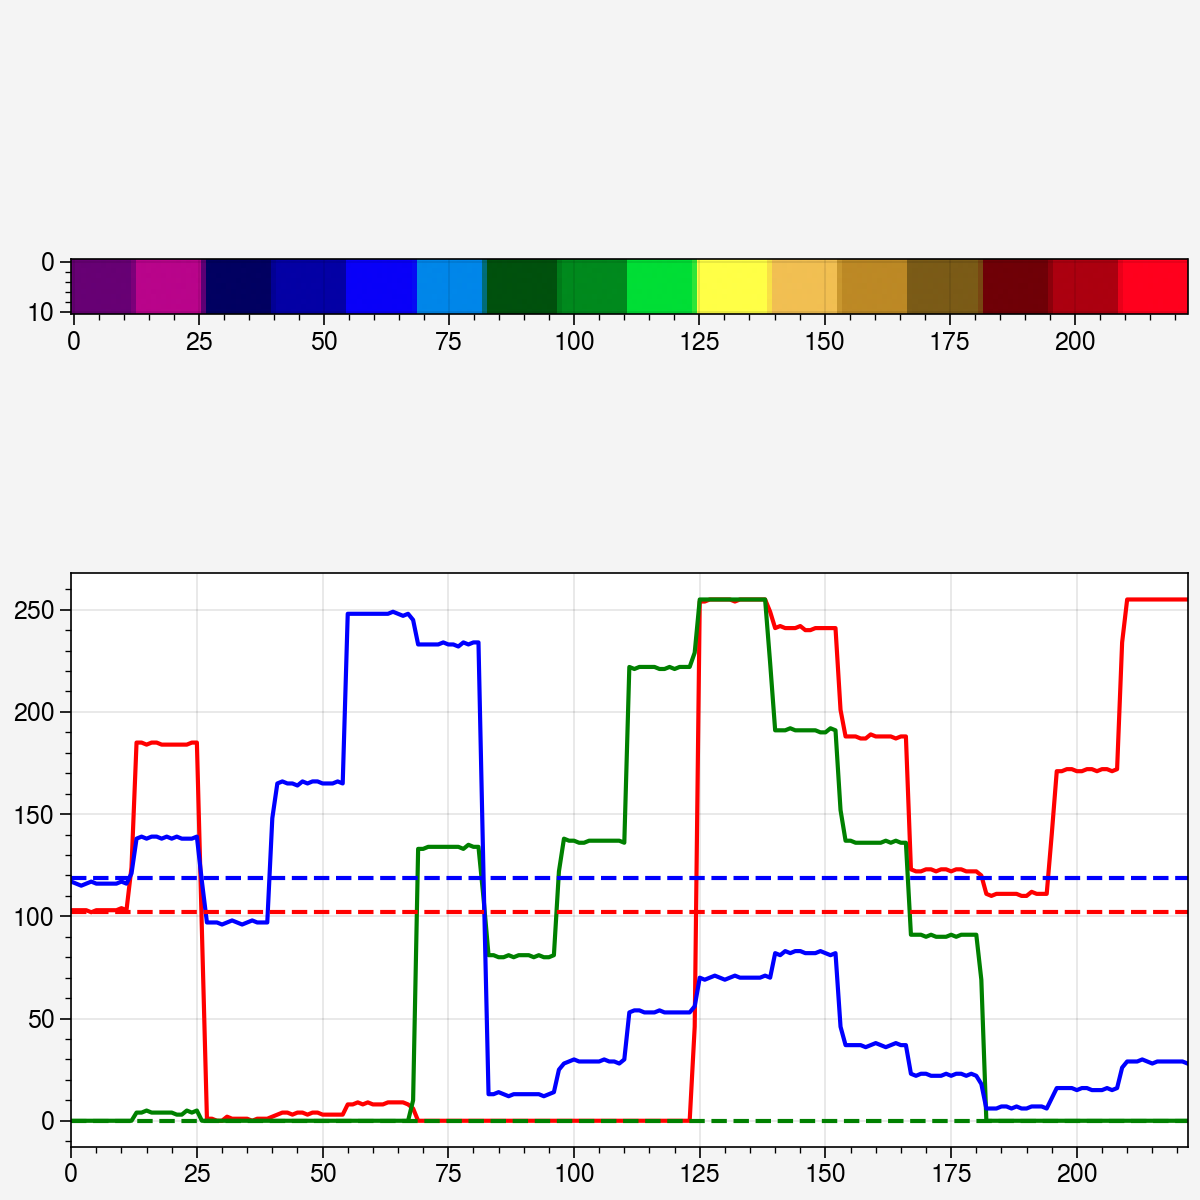

In [639]:
fig, ax = uplt.subplots(nrows=2, share=False, height=6, width=6)
ax[0].imshow(key)
ax[1].plot(key[5, :, 0], color='r')
ax[1].plot(key[5, :, 1], color='g')
ax[1].plot(key[5, :, 2], color='b')

ax[1].axhline(102, color='r', ls='--')
ax[1].axhline(0, color='g', ls='--')
ax[1].axhline(119, color='b', ls='--')

In [640]:
files

['001-baffin_bay-500km-20220911.aqua.cloudfraction.250m.tiff',
 '001-baffin_bay-500km-20220911.terra.cloudfraction.250m.tiff',
 '002-baffin_bay-500km-20150312.aqua.cloudfraction.250m.tiff',
 '002-baffin_bay-500km-20150312.terra.cloudfraction.250m.tiff',
 '003-baffin_bay-500km-20120419.aqua.cloudfraction.250m.tiff',
 '003-baffin_bay-500km-20120419.terra.cloudfraction.250m.tiff',
 '004-baffin_bay-500km-20190925.aqua.cloudfraction.250m.tiff',
 '004-baffin_bay-500km-20190925.terra.cloudfraction.250m.tiff',
 '005-baffin_bay-500km-20130308.aqua.cloudfraction.250m.tiff',
 '005-baffin_bay-500km-20130308.terra.cloudfraction.250m.tiff',
 '006-baffin_bay-500km-20220530.aqua.cloudfraction.250m.tiff',
 '006-baffin_bay-500km-20220530.terra.cloudfraction.250m.tiff',
 '007-baffin_bay-500km-20070825.aqua.cloudfraction.250m.tiff',
 '007-baffin_bay-500km-20070825.terra.cloudfraction.250m.tiff',
 '008-baffin_bay-500km-20110506.aqua.cloudfraction.250m.tiff',
 '008-baffin_bay-500km-20110506.terra.cloudfract

In [641]:
red = rgb_img[:, :, 0].astype(float)
green = rgb_img[:, :, 1].astype(float)
blue = rgb_img[:, :, 2].astype(float)
cloud_free = (green < 1) & (np.abs(red - 102) < 1) & (np.abs(blue - 119) < 1)
cloud_covered = (green < 6) & (red > 250) &  np.abs(blue < 30)

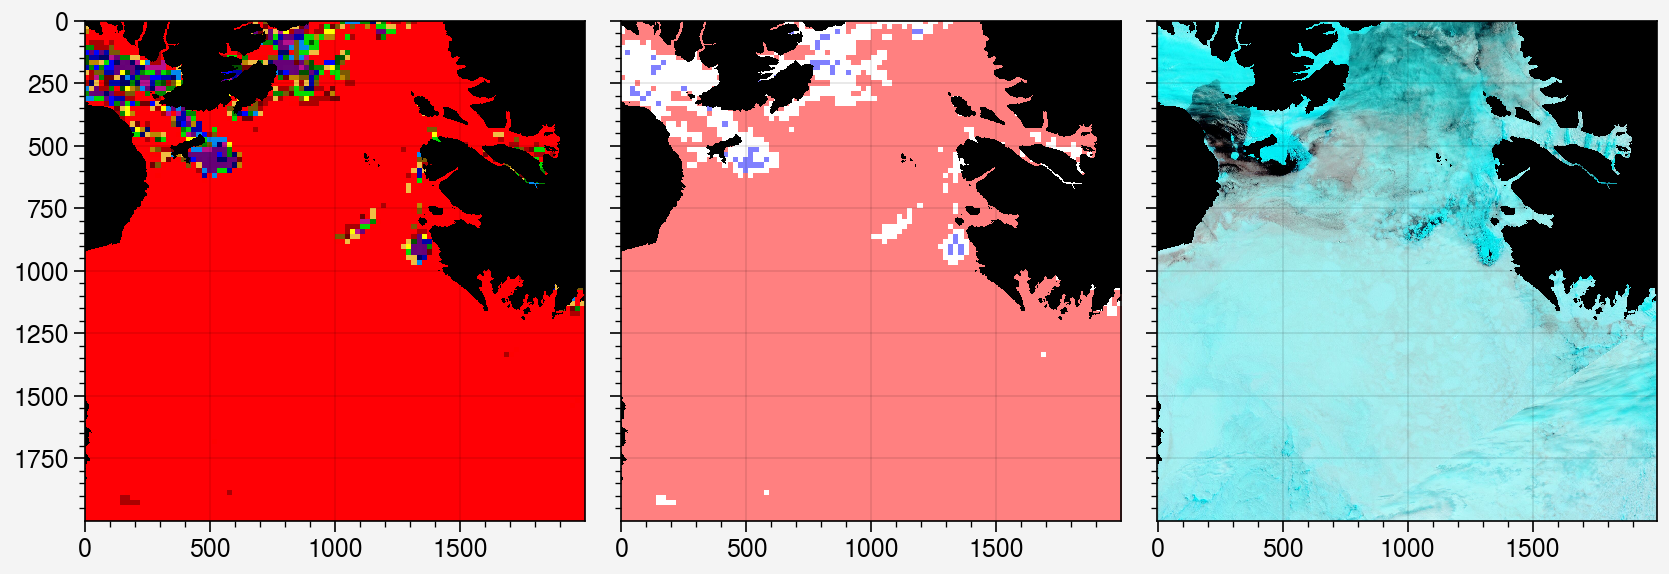

In [642]:
fig, axs = uplt.subplots(ncols=3)
axs[0].imshow(rgb_img.astype(int))
axs[1].imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
axs[1].imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
axs[2].imshow(fc_img)

for ax in axs:
    ax.imshow(np.ma.masked_array(land_img, land_img==0), color='k')

Selecting the extremes is faster than the pixel-to-percentage mapping. Since we are initializing a map of points to then verify

2d uniform random sample

In [643]:
g.choice(range(4, 20), (2, 4))

array([[ 9, 13, 17,  8],
       [19,  8,  6, 14]])

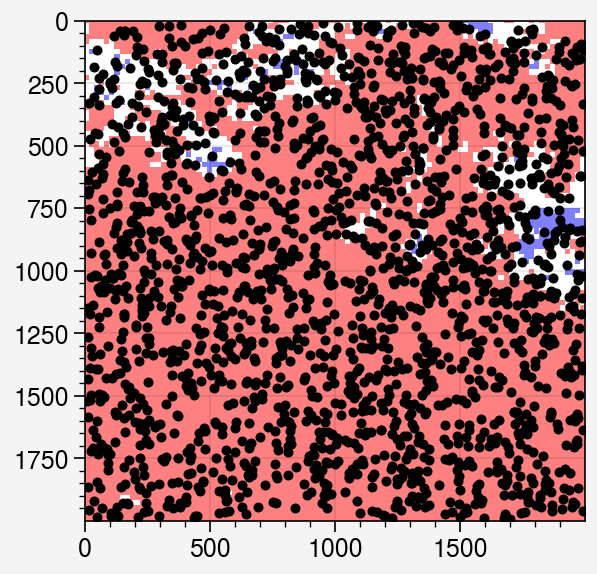

In [644]:
g = np.random.default_rng(seed=2340)
points = g.choice(range(8, 2000-8), (2, 2000)) 
fig, ax = uplt.subplots()
ax.imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax.imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
ax.scatter(points[0,:], points[1, :], color='k', marker='.')

We draw a random sample of locations within each index with the constraint that points are separated by at least 10 km, which is two pixels in the cloud mask product.



In [645]:
import scipy
# distance between all points
n = len(points[1, :])
keep_n = 500
keep = np.ones(n)
jcomp = np.arange(0, n)
min_dx = 50
d = pd.DataFrame(scipy.spatial.distance_matrix(points.T, points.T),
                 columns=jcomp, index=jcomp)
for idx in range(0, n):
    if keep[idx] > 0:
        di = d.loc[idx, jcomp != idx]
        keep[di[di <= min_dx].index] = 0
sample_points = points[:, keep > 0][:, 1:keep_n]


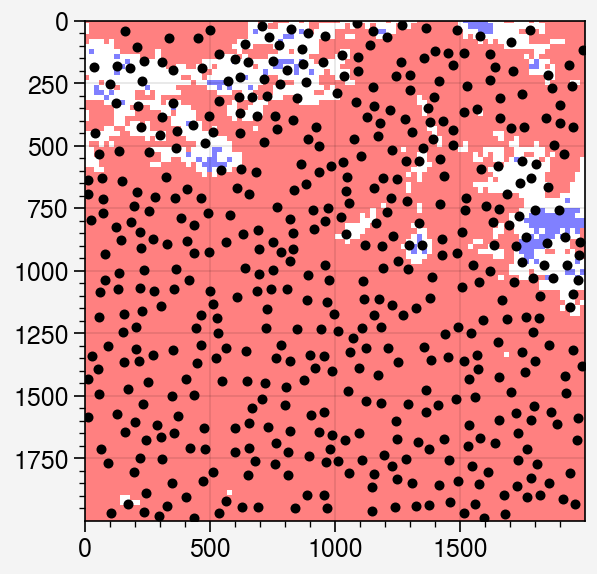

In [646]:
fig, ax = uplt.subplots()
ax.imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax.imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
ax.scatter(sample_points[0,:], sample_points[1, :], color='k', marker='.')

# Turning points to samples
- Expand using 16x16 template
- Somehow there are still points not being saved, or overlapping, which is dumb
- So, 

In [647]:
Z = np.zeros((2000, 2000))
for idx in range(0, len(sample_points.T)):
    Z[sample_points[0, idx], sample_points[1, idx]] = 1
sample_patches = skim.dilation(Z, skim.footprint_rectangle((16,16)))
sample_patches = skimage.morphology.label(sample_patches)


In [648]:
from skimage.measure import regionprops_table

df = pd.DataFrame(regionprops_table(sample_patches, fc_img, properties=["area", "label", "bbox", "centroid", "intensity_mean"]))
df_cloud_free_fraction = pd.DataFrame(regionprops_table(sample_patches, intensity_image=cloud_free, properties=["label", "intensity_mean"])).rename(
    {'intensity_mean': 'cloud_free_pixel_fraction'}, axis=1)
df_cloudy_fraction = pd.DataFrame(regionprops_table(sample_patches, intensity_image=cloud_covered, properties=["label", "intensity_mean"])).rename(
    {'intensity_mean': 'cloudy_pixel_fraction'}, axis=1)
df_sic = pd.DataFrame(regionprops_table(sample_patches, intensity_image=sic_img, properties=["label", "intensity_mean"])).rename(
    {'intensity_mean': 'asi_sea_ice_concentration'}, axis=1)
df_sic['asi_sea_ice_concentration'] = df_sic['asi_sea_ice_concentration'] / 255
df_land = pd.DataFrame(regionprops_table(sample_patches, intensity_image=land_img > 0, properties=["label", "intensity_mean"])).rename(
    {'intensity_mean': 'land_fraction'}, axis=1)

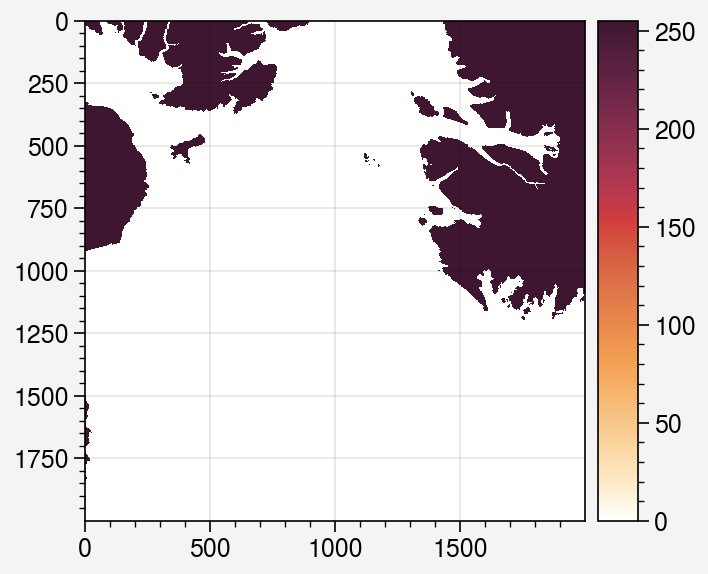

In [649]:
fig, ax = uplt.subplots()
ax.imshow(land_img, colorbar='r')

In [650]:
df_all = df.merge(
    df_cloud_free_fraction, left_on='label', right_on='label').merge(
        df_cloudy_fraction, left_on='label', right_on='label').merge(
            df_sic, left_on='label', right_on='label').merge(
            df_land, left_on='label', right_on='label')

In [651]:
df_all.head()

,area,label,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,intensity_mean-0,intensity_mean-1,intensity_mean-2,intensity_mean-3,cloud_free_pixel_fraction,cloudy_pixel_fraction,asi_sea_ice_concentration,land_fraction
0,256.0,1,1,630,17,646,8.5,637.5,48.843750,226.640625,230.687500,255.0,0.0,1.0000,0.000000,0.726562
1,256.0,2,1,683,17,699,8.5,690.5,84.562500,241.855469,243.667969,255.0,0.0,0.4375,0.184559,0.359375
2,256.0,3,3,1578,19,1594,10.5,1585.5,23.957031,236.890625,240.976562,255.0,1.0,0.0000,0.000000,1.000000
3,256.0,4,4,1425,20,1441,11.5,1432.5,126.949219,190.867188,189.101562,255.0,0.0,1.0000,0.426471,0.203125
4,256.0,5,16,788,32,804,23.5,795.5,57.257812,235.750000,238.632812,255.0,0.0,0.0000,0.030193,1.000000


In [652]:
df_all.rename({
    'bbox-0': 'min_row',
    'bbox-1': 'min_col',
    'bbox-2': 'max_row',
    'bbox-3': 'max_col',
    'centroid-0': 'row_centroid',
    'centroid-1': 'col_centroid',
    'intensity_mean-0': 'band_7_mean_reflectance',
    'intensity_mean-1': 'band_2_mean_reflectance',
    'intensity_mean-2': 'band_1_mean_reflectance',
}, inplace=True, axis=1
)

In [653]:
df_all

,area,label,min_row,min_col,max_row,max_col,row_centroid,col_centroid,band_7_mean_reflectance,band_2_mean_reflectance,band_1_mean_reflectance,intensity_mean-3,cloud_free_pixel_fraction,cloudy_pixel_fraction,asi_sea_ice_concentration,land_fraction
0,256.0,1,1,630,17,646,8.5,637.5,48.843750,226.640625,230.687500,255.0,0.0,1.0000,0.000000,0.726562
1,256.0,2,1,683,17,699,8.5,690.5,84.562500,241.855469,243.667969,255.0,0.0,0.4375,0.184559,0.359375
2,256.0,3,3,1578,19,1594,10.5,1585.5,23.957031,236.890625,240.976562,255.0,1.0,0.0000,0.000000,1.000000
3,256.0,4,4,1425,20,1441,11.5,1432.5,126.949219,190.867188,189.101562,255.0,0.0,1.0000,0.426471,0.203125
4,256.0,5,16,788,32,804,23.5,795.5,57.257812,235.750000,238.632812,255.0,0.0,0.0000,0.030193,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,256.0,495,1964,1582,1980,1598,1971.5,1589.5,160.417969,221.992188,226.488281,255.0,0.0,1.0000,0.984069,0.000000
495,256.0,496,1965,928,1981,944,1972.5,935.5,154.015625,228.671875,230.777344,255.0,0.0,1.0000,1.000000,0.000000
496,256.0,497,1969,878,1985,894,1976.5,885.5,159.562500,230.257812,231.964844,255.0,0.0,1.0000,0.992034,0.000000
497,256.0,498,1980,1372,1996,1388,1987.5,1379.5,170.394531,236.531250,237.851562,255.0,0.0,1.0000,1.000000,0.000000


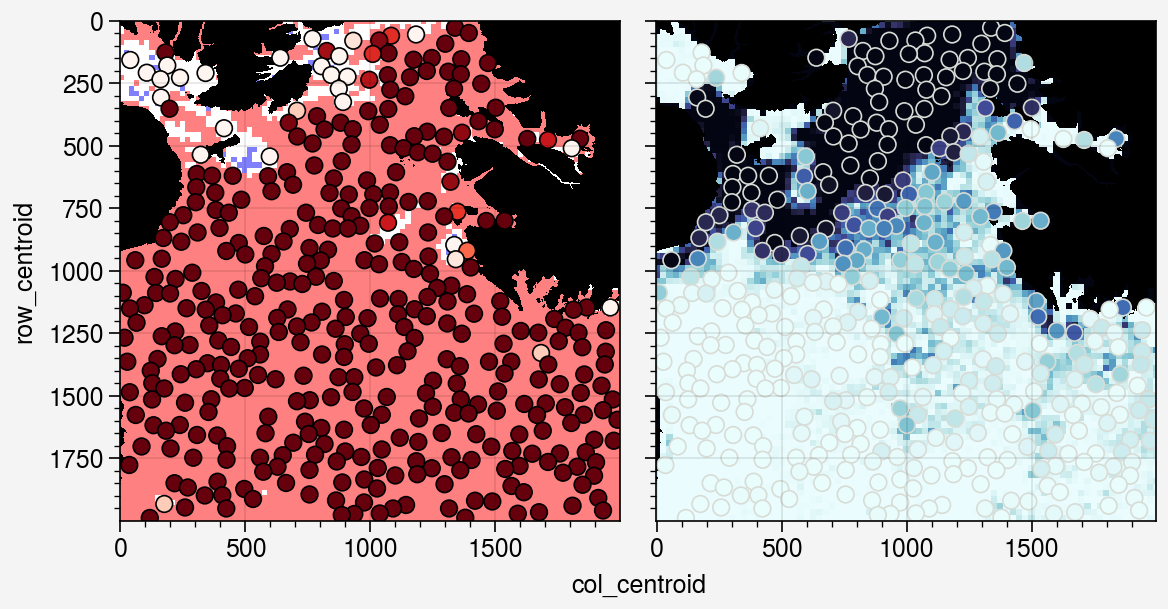

In [654]:
fig, axs = uplt.subplots(ncols=2)
idx = df_all.land_fraction == 0
ax = axs[0]
ax.imshow(np.ma.masked_array(cloud_free.astype(int), ~cloud_free), color='b', alpha=0.5)
ax.imshow(np.ma.masked_array(cloud_covered.astype(int), ~cloud_covered), color='r', alpha=0.5)
ax.imshow(np.ma.masked_array(land_img, land_img==0), color='k', alpha=1)
ax.scatter(df_all.col_centroid[idx],
           df_all.row_centroid[idx],
           c=df_all['cloudy_pixel_fraction'][idx],
           cmap='reds', edgecolor='k', marker='o', vmin=0, vmax=1)

ax = axs[1]
ax.imshow(sic_img, cmap='ice', vmin=0, vmax=255)
ax.imshow(np.ma.masked_array(land_img, land_img==0), color='k', alpha=1)
ax.scatter(df_all.col_centroid[idx],
           df_all.row_centroid[idx],
           c=df_all['asi_sea_ice_concentration'][idx],
           cmap='ice', edgecolor='light gray', marker='o', vmin=0, vmax=1)

In [655]:
df_all.loc[:, "init_cloud_free_water"] = (df_all["asi_sea_ice_concentration"] == 0) # & (df_all["land_fraction"] == 0) & (df_all["cloud_free_pixel_fraction"] > 0.9)
df_all.loc[:, "init_cloud_free_ice"] = (df_all["asi_sea_ice_concentration"] > 0.85) & (df_all["land_fraction"] == 0) & (df_all["cloud_free_pixel_fraction"] > 0.9)
df_all.loc[:, "init_cloudy_water"] = (df_all["asi_sea_ice_concentration"] == 0) & (df_all["land_fraction"] == 0) & (df_all["cloudy_pixel_fraction"] > 0.9)
df_all.loc[:, "init_cloudy_ice"] = (df_all["asi_sea_ice_concentration"] > 0.85) & (df_all["land_fraction"] == 0) & (df_all["cloudy_pixel_fraction"] > 0.9)

TBD:
1. Subset the dataframe to just the ones with no land in the patch and with at least one "true" category
2. Use the bounding box to define a geometry
3. Use geopandas to export the result to file
4. Loop through all cases and generate tables for each
5. Use QGIS to evaluate the bounding boxes and tag boxes which should be rejected or re-categorized, ideally in bulk
6. Analysis: How often are there 100% MODIS clouds which get rejected by an observer?
7. Analysis: How often are there 0% ASI SIC which contain obvious ice?

(array([0.00108076, 0.00108076, 0.00162114, 0.00216153, 0.00108076,
        0.00351248, 0.00675477, 0.00810572, 0.01972393, 0.02972099]),
 array([ 38.16796875,  51.52929688,  64.890625  ,  78.25195312,
         91.61328125, 104.97460938, 118.3359375 , 131.69726562,
        145.05859375, 158.41992188, 171.78125   ]),
 <BarContainer object of 10 artists>)

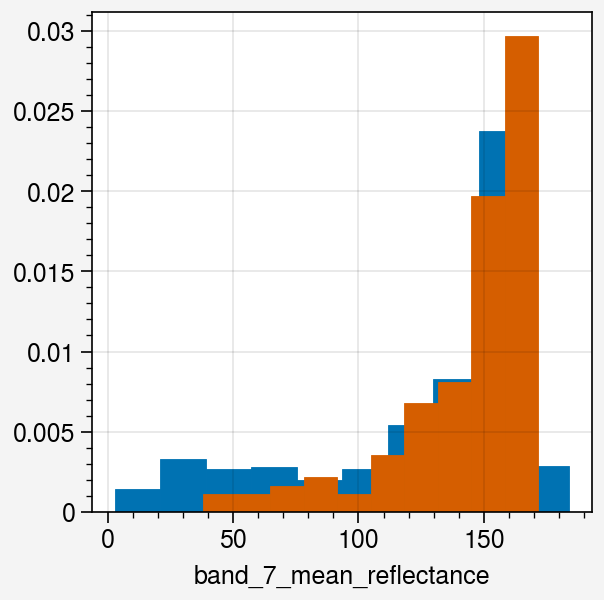

In [657]:
fig, ax = uplt.subplots()
ax.hist(df_all.band_7_mean_reflectance, density=True)
ax.hist(df_all.band_7_mean_reflectance[df_all.init_cloudy_ice | df_all.init_cloudy_water], density=True)

In [372]:
red = rgb_img[:, :, 0]
green = rgb_img[:, :, 1]
blue = rgb_img[:, :, 2]

In [127]:
tol = 5
img = np.zeros((n, m))
for idx in [15]:
    data = bin_mean_values.iloc[idx, :]
    sel = np.abs(blue - data.b) < tol #) & (np.abs(green - data.g) < tol) & (np.abs(blue - data.b) < tol)
    img[sel] = idx

In [128]:
np.max(img)

np.float64(0.0)

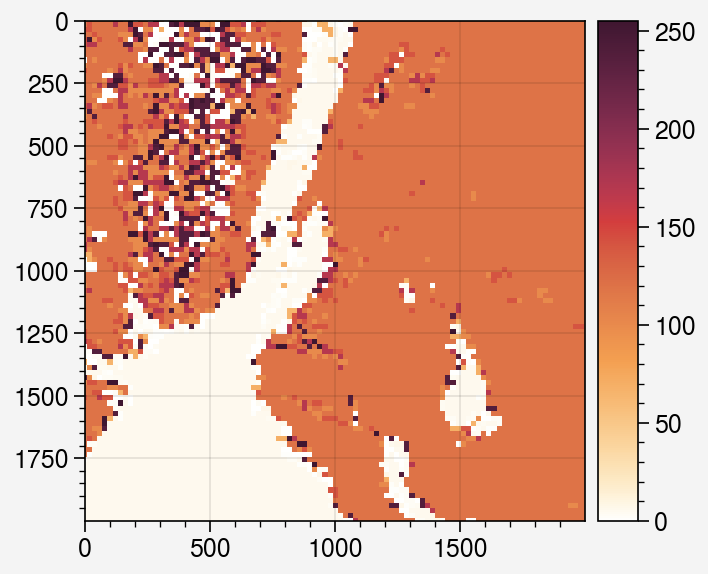

In [133]:
fig, ax  = uplt.subplots()
ax.imshow(blue, colorbar='r')

In [86]:
 data = bin_mean_values.iloc[idx, :]
    ax[idx, 0].imshow((np.abs(red - data.r) < 5).astype(int))

16

# Speeding this up: ~100% and ~0% cloud masks


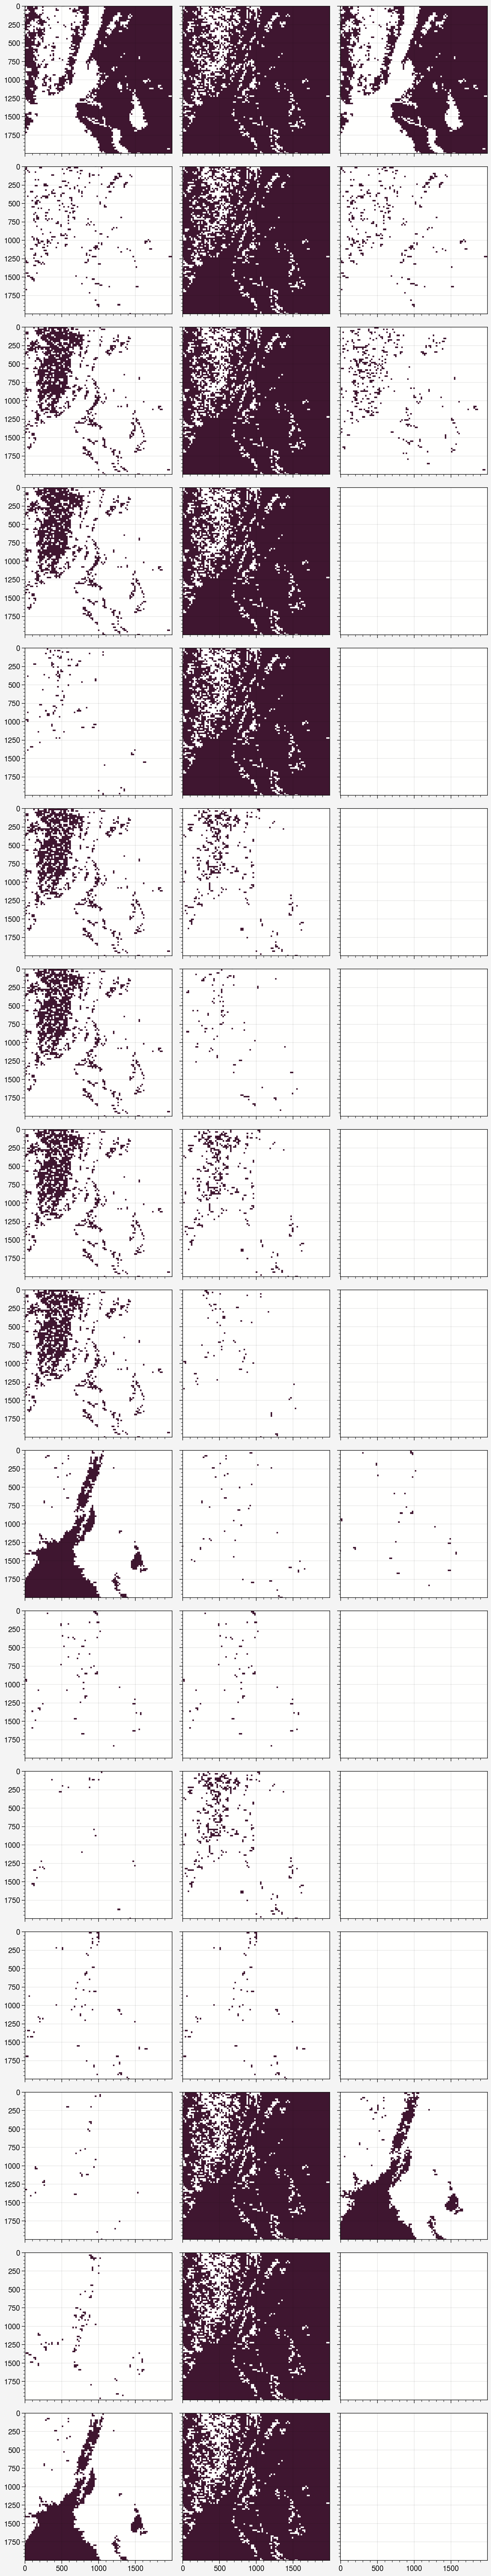

In [116]:
fig, ax = uplt.subplots(ncols=3, nrows=16)
for idx in range(0, len(bin_mean_values)):
    data = bin_mean_values.iloc[idx, :]
    ax[idx, 0].imshow((np.abs(red - data.r) < 5).astype(int))
    ax[idx, 1].imshow((np.abs(green - data.g) < 5).astype(int))
    ax[idx, 2].imshow((np.abs(blue - data.b) < 5).astype(int))

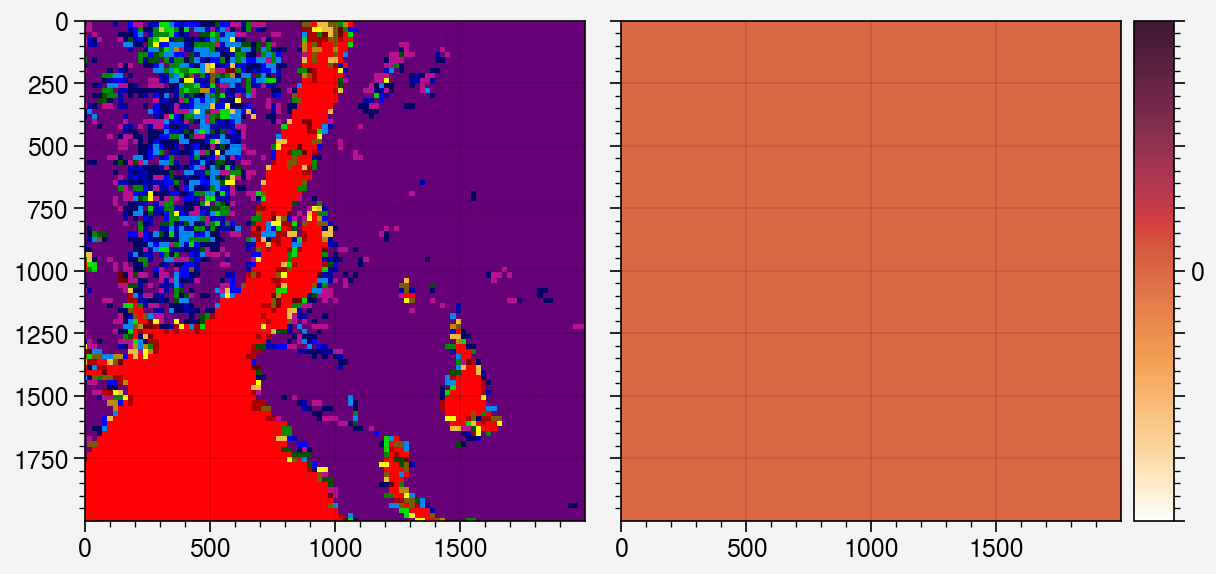

In [64]:
low_cloud_fraction = (np.abs(red - 103) < 5) # & (green <= 1) & (np.abs(blue - 116) < 5)
fig, ax = uplt.subplots(ncols=2)
ax[0].imshow(rgb_img)
ax[1].imshow(img, colorbar='r')


In [42]:
import skimage


Object `skimage.color.rgb_colors` not found.


In [26]:
%%time
gray_img = np.zeros((400, 400))
for i in range(400):
    for j in range(400):
        p = rgb_img[i, j, :-1]
        gray_img[i, j] = np.sqrt(np.sum((bin_mean_values - p)**2, axis=1)).idxmin()


CPU times: user 23.3 s, sys: 484 ms, total: 23.8 s
Wall time: 23.5 s


In [29]:
(2000 * 2000) / (400 * 400) * 23.5 / 60

9.791666666666666

In [23]:
# perhaps need to drop alpha channel?
pixel_min(rgb_img[0:200, 0:200, 0:3][0, 0])

np.float64(96.875)

In [4]:
import ultraplot as uplt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [40.625..78.125].


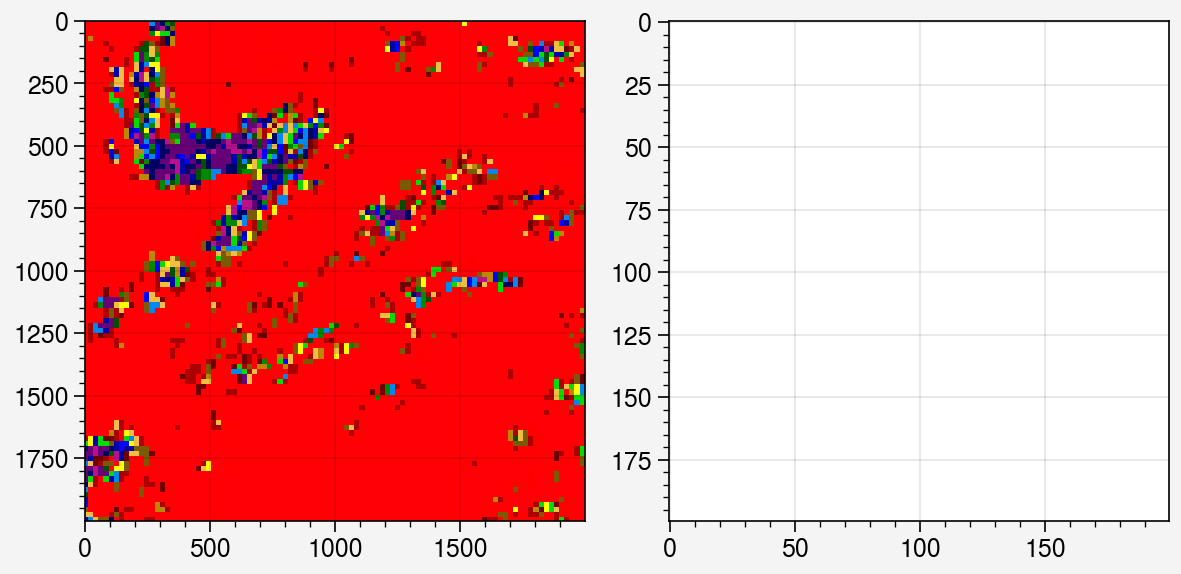

In [19]:
fig, ax = uplt.subplots(ncols=2, share=False)
ax[0].imshow(rgb_img)
ax[1].imshow(gray_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [40.625..78.125].


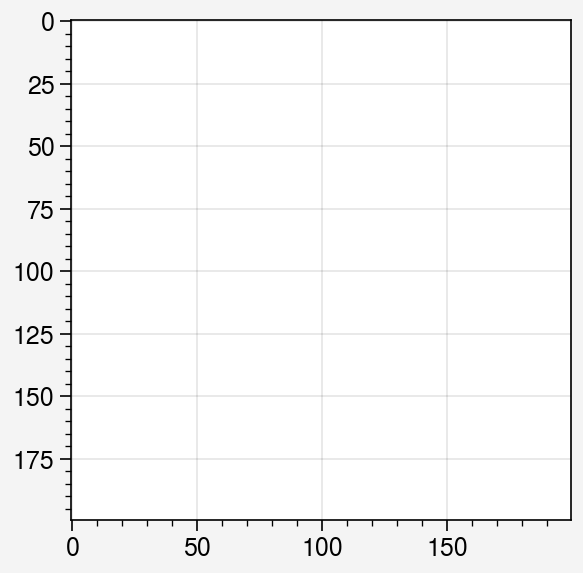

In [21]:
fig, ax = uplt.subplots()
ax.imshow(gray_img)